# AI Financial Fraud Detection System

## Data Preprocessing and Model Building

**Project Type:** Binary Classification

**Domain:** Financial Technology (FinTech)

**Objective:** Prepare the dataset for machine learning, train multiple classification models, evaluate their performance, and save the best model for deployment.

## Objective

Import the required libraries for data preprocessing, model training, evaluation, and model saving.

In [4]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Objective

Load the dataset for preprocessing and model building.

In [5]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
file_path = "/content/drive/MyDrive/AI-Financial-Fraud-Detection/Data/Raw/creditcard.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 3. Data Preprocessing

## Objective

Prepare the dataset before training machine learning models by removing duplicate records and separating features from the target variable.

In [7]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

Duplicate Records: 1081


In [8]:
# Remove duplicate records
df = df.drop_duplicates()

print("Duplicate records removed successfully.")

Duplicate records removed successfully.


In [9]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 283726
Columns : 31


In [10]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (283726, 30)
Target Shape   : (283726,)


### Observation

- Duplicate records were removed from the dataset.
- The dataset was divided into input features (`X`) and the target variable (`y`).
- The target variable represents whether a transaction is genuine (`0`) or fraudulent (`1`).

# 4. Train-Test Split

## Objective

Split the dataset into training and testing sets while preserving the original class distribution.

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (226980, 30)
Testing Set  : (56746, 30)


In [14]:
print("Training Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Class Distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing Class Distribution:
Class
0    56651
1       95
Name: count, dtype: int64


### Observation

- The dataset was split into **80% training data** and **20% testing data**.
- The `stratify` parameter was used to maintain the original class distribution in both datasets.
- The training dataset will be used for model learning, while the testing dataset will be used for performance evaluation.

# 5. Feature Scaling

## Objective

Scale the `Time` and `Amount` features using `RobustScaler` to reduce the impact of outliers.

In [15]:
from sklearn.preprocessing import RobustScaler

In [16]:
scaler = RobustScaler()

In [17]:
X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [18]:
X_train[["Time", "Amount"]].head()

,Time,Amount
226238,0.701730,0.137472
134253,-0.048166,-0.209119
186465,0.496931,-0.098808
149493,0.076666,-0.066242
18461,-0.649581,0.026608


### Observation

- The `Time` and `Amount` features were scaled using `RobustScaler`.
- `RobustScaler` is suitable because these features contain outliers.
- The scaler was fitted only on the training data and then applied to the testing data to avoid data leakage.

# 6. Handling Class Imbalance (SMOTE)

## Objective

Balance the training dataset using SMOTE (Synthetic Minority Over-sampling Technique) to improve the model's ability to detect fraudulent transactions.

In [19]:
from imblearn.over_sampling import SMOTE

In [20]:
print("Class Distribution Before SMOTE:")
print(y_train.value_counts())

Class Distribution Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64


In [21]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [22]:
print("Class Distribution After SMOTE:")
print(y_train_resampled.value_counts())

Class Distribution After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


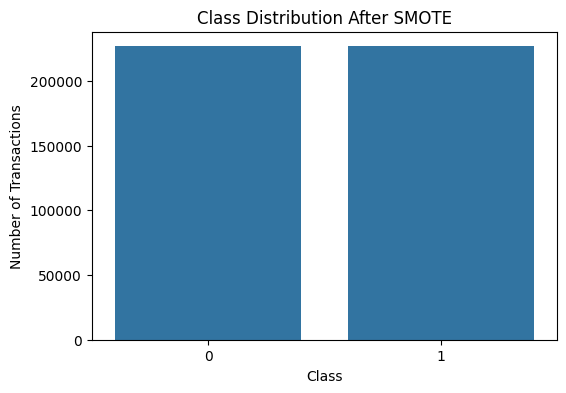

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_resampled)

plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

### Observation

- Before applying SMOTE, the training dataset was highly imbalanced.
- SMOTE generated synthetic samples for the minority class (fraud).
- After applying SMOTE, both classes contain an equal number of samples.
- Only the training dataset was resampled, while the testing dataset remained unchanged to ensure fair model evaluation.

# 7. Model Training

## Objective

Train multiple machine learning models and compare their performance for fraud detection.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [25]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss")
}

In [26]:
for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
XGBoost trained successfully.


### Observation

- Four machine learning models were trained using the balanced training dataset.
- Each model learned from the same training data, allowing a fair performance comparison in the next section.

# 8. Model Evaluation

## Objective

Evaluate each trained model using standard classification metrics and compare their performance.

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [28]:
results = []

def evaluate_model(model, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



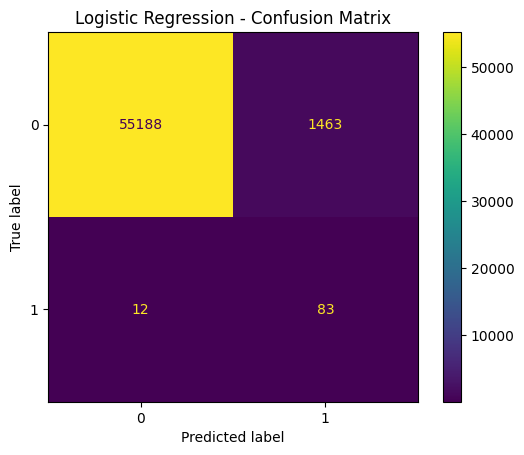

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.39      0.69      0.50        95

    accuracy                           1.00     56746
   macro avg       0.69      0.85      0.75     56746
weighted avg       1.00      1.00      1.00     56746



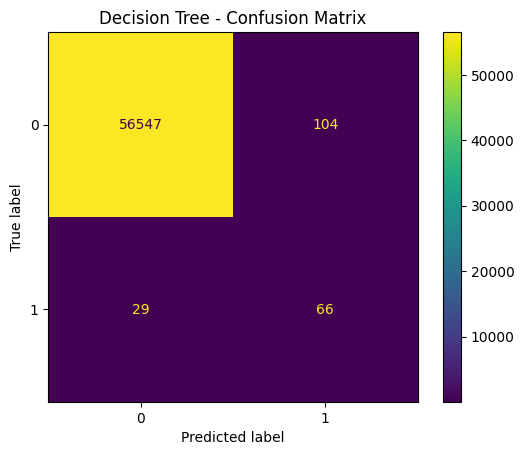

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.78      0.84        95

    accuracy                           1.00     56746
   macro avg       0.96      0.89      0.92     56746
weighted avg       1.00      1.00      1.00     56746



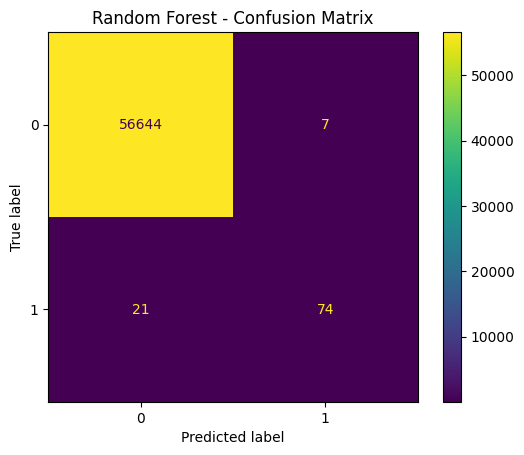

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.75      0.80      0.78        95

    accuracy                           1.00     56746
   macro avg       0.88      0.90      0.89     56746
weighted avg       1.00      1.00      1.00     56746



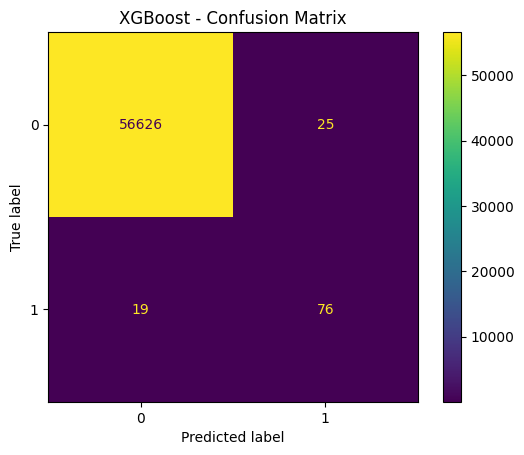

In [29]:
for name, model in models.items():
    evaluate_model(model, name)

### Observation

- Each model was evaluated using the same testing dataset.
- Multiple evaluation metrics were used instead of relying only on accuracy.
- The confusion matrix and classification report provide detailed insights into model performance.

# 9. Model Comparison

## Objective

Compare the performance of all trained models and identify the best model for fraud detection.

In [33]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["F1 Score", "Precision"],
    ascending=False
).reset_index(drop=True)

results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(4)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.9995,0.9136,0.7789,0.8409,0.9590
1,XGBoost,0.9992,0.7525,0.8000,0.7755,0.9652
2,Decision Tree,0.9977,0.3882,0.6947,0.4981,0.8465
3,Logistic Regression,0.9740,0.0537,0.8737,0.1012,0.9600


In [31]:
results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(4)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.9992,0.7525,0.8000,0.7755,0.9652
1,Logistic Regression,0.9740,0.0537,0.8737,0.1012,0.9600
2,Random Forest,0.9995,0.9136,0.7789,0.8409,0.9590
3,Decision Tree,0.9977,0.3882,0.6947,0.4981,0.8465


In [32]:
best_model_name = results_df.iloc[0]["Model"]

print(f"Best Model: {best_model_name}")

Best Model: XGBoost


### Observation

- Four machine learning models were trained and evaluated.
- Random Forest achieved the best overall performance with the highest Precision and F1-Score.
- Based on the evaluation results, Random Forest was selected as the final model for this project.on overall evaluation metrics, with special attention to ROC-AUC, Precision, Recall, and F1-Score.

# 10. Feature Importance

## Objective

Identify the most important features used by the Random Forest model for fraud detection.

In [34]:
# Get the trained Random Forest model
rf_model = models["Random Forest"]

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 10 features
feature_importance.head(10)

,Feature,Importance
14,V14,0.198531
10,V10,0.120434
12,V12,0.095106
4,V4,0.094902
17,V17,0.090861
11,V11,0.057484
16,V16,0.056414
3,V3,0.054254
2,V2,0.037967
9,V9,0.025388


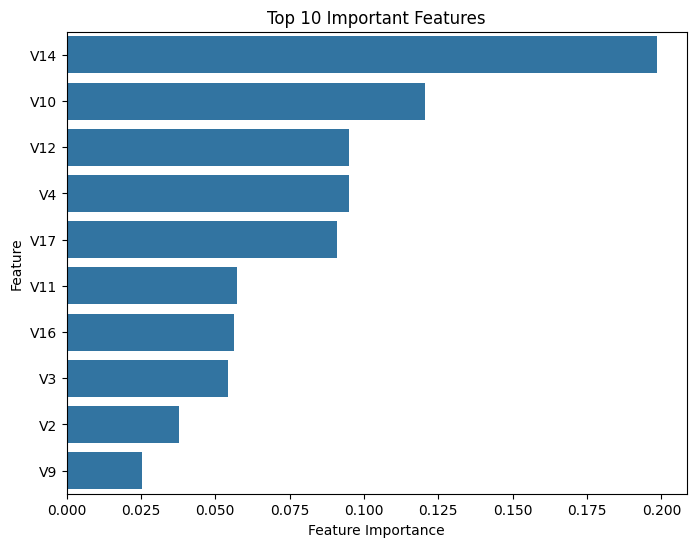

In [35]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

### Observation

- The Random Forest model assigns different importance scores to each feature.
- The top-ranked features contribute the most to fraud detection.
- Feature importance helps us understand which variables have the greatest influence on the model's predictions.

# 11. Save Model

## Objective

Save the trained Random Forest model and the fitted scaler for future predictions and deployment.

In [39]:
import os
import joblib

# Folder where model files will be stored
model_path = "/content/drive/MyDrive/AI-Financial-Fraud-Detection/Models"

# Create folder if it doesn't exist
os.makedirs(model_path, exist_ok=True)

# Save model and scaler
joblib.dump(rf_model, os.path.join(model_path, "fraud_detection_model.pkl"))
joblib.dump(scaler, os.path.join(model_path, "scaler.pkl"))

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [38]:
import os
print(os.listdir())

['.config', 'scaler.pkl', 'fraud_detection_model.pkl', 'drive', 'sample_data']


### Observation

- The trained Random Forest model was saved as `fraud_detection_model.pkl`.
- The fitted `RobustScaler` was saved as `scaler.pkl`.
- These files will be used later during deployment without retraining the model.

# 12. Conclusion

## Summary

- Duplicate records were removed from the dataset.
- The dataset was split into training and testing sets.
- The `Time` and `Amount` features were scaled using `RobustScaler`.
- Class imbalance was handled using **SMOTE**.
- Four machine learning models were trained and evaluated.
- **Random Forest** achieved the best overall performance and was selected as the final model.
- The trained model and scaler were saved for deployment.